# 03 -- A neural-network potential from scratch

**Energy is a neural net. Forces come free from autograd.**

In Notebook 01 we wrote the force by hand. In Notebook 02 we saw why that breaks. Now we fix it: we keep the entire MD loop unchanged and swap in a neural network that *learns* the energy from data, with forces computed automatically by differentiation.

The idea fits in one sentence:

> Train a network to predict $V(\mathbf{r})$. Then $\mathbf{F}_i = -\nabla_{\mathbf{r}_i} V$ comes from `torch.autograd`, exactly like the finite-difference check in Notebook 01, but exact and fast.

By the end of this notebook you will have:

1. generated training data from the Lennard-Jones potential (so we can check the learned result),
2. built and trained a tiny MLP that predicts potential energy,
3. computed forces via autograd and verified them with the same gradient check as Notebook 01,
4. run a full MD trajectory with the learned potential and confirmed energy conservation.

> **Prerequisites:** Notebooks 01 and 02. You need a basic understanding of PyTorch (`tensor`, `grad_fn`, `backward`).

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from afs.md import (
    lj_energy, lj_forces, run_md,
    triangular_lattice, disk_cluster, thermal_velocities,
)

torch.manual_seed(0)
np.random.seed(0)

## 1. Generate training data

We will train on the Lennard-Jones potential -- not because LJ is interesting, but because we know the ground truth and can check our work. The exact same pipeline works for *ab initio* quantum-chemistry data later.

**What does training data look like?** Each example is:
- **input:** the positions of all atoms -- an $(N, d)$ array,
- **label:** the total potential energy -- a single scalar.

We sample random configurations by perturbing atoms from a lattice, compute the LJ energy for each, and collect them into a dataset.

dataset: 89 configs of 9 atoms in 2D
energy range: [-11.65, 49.08]


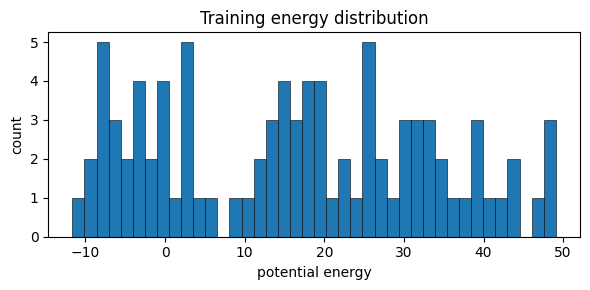

In [2]:
def make_dataset(n_samples=2000, n_atoms=9, noise_scale=0.3):
    """
    Return (X, y) where
        X : (n_samples, n_atoms, 2) -- positions
        y : (n_samples,)            -- LJ energies
    """
    base = triangular_lattice(3, 3)          # 9-atom 3x3 triangular lattice
    rng = np.random.default_rng(1)
    configs, energies = [], []
    for _ in range(n_samples):
        pos = base + noise_scale * rng.standard_normal(base.shape)
        E = lj_energy(pos)
        if abs(E) < 50:                      # skip unphysically compressed configs
            configs.append(pos)
            energies.append(E)
    return np.array(configs), np.array(energies)

X, y = make_dataset()
print(f'dataset: {len(X)} configs of {X.shape[1]} atoms in {X.shape[2]}D')
print(f'energy range: [{y.min():.2f}, {y.max():.2f}]')

plt.figure(figsize=(6, 3))
plt.hist(y, bins=40, edgecolor='k', lw=0.4)
plt.xlabel('potential energy'); plt.ylabel('count')
plt.title('Training energy distribution')
plt.tight_layout(); plt.show()

## 2. Features: how to represent a configuration

A plain neural network takes a fixed-size vector as input. But raw $(x, y)$ coordinates have a problem: if we rotate or translate the cluster, the energy should not change (physics is symmetric). A network trained on raw coordinates would have to learn that symmetry from scratch.

The standard fix is to feed the network **pairwise distances** instead. Distances are invariant to translation and rotation. For $N$ atoms there are $N(N-1)/2$ unique pairs. We **sort** them so the representation is also invariant to the arbitrary ordering of atoms.

> **Important:** because we sort, we must sort *everywhere* -- in training, in the energy, and in the force. The force path below sorts while keeping the autograd graph (`torch.sort` / a value-sorted `torch.stack` is differentiable), so the force is the gradient of exactly the same function we trained. This is a minimal but working feature set; Notebooks 04 and 05 replace it with smarter representations.

In [3]:
def pairwise_distances(pos):
    """All pairwise distances for a single configuration, sorted ascending (numpy)."""
    n = len(pos)
    dists = []
    for i in range(n):
        for j in range(i + 1, n):
            dists.append(np.linalg.norm(pos[i] - pos[j]))
    return np.sort(dists)

def pairwise_distances_torch(pos):
    """Same, for a torch (N, d) tensor, SORTED and keeping the autograd graph.

    torch.sort is differentiable: it only permutes the values, so gradients flow
    back to the original positions. Sorting here (not just in numpy) is what makes
    the autograd force consistent with the sorted features the model was trained on.
    """
    n = pos.shape[0]
    dists = []
    for i in range(n):
        for j in range(i + 1, n):
            diff = pos[i] - pos[j]
            dists.append(torch.sqrt((diff * diff).sum()))
    d = torch.stack(dists)
    return torch.sort(d).values          # sorted, graph preserved

X_feat = np.array([pairwise_distances(x) for x in X])
print(f'feature shape: {X_feat.shape} (one sorted distance vector per config)')

# Sanity: translation invariance
pos_shifted = X[0] + np.array([100.0, 200.0])
print('translation-invariant:', np.allclose(X_feat[0], pairwise_distances(pos_shifted)))

# Sanity: the torch path matches the numpy path (both sorted)
p = torch.tensor(X[0], dtype=torch.float64)
print('torch path == numpy path:',
      np.allclose(pairwise_distances_torch(p).detach().numpy(), X_feat[0]))

feature shape: (89, 36) (one sorted distance vector per config)
translation-invariant: True
torch path == numpy path: True


## 3. Build and train the network

The network is a simple MLP: a few fully-connected layers with SiLU activations. We keep it small -- easier to debug and plenty for a 9-atom LJ system. The loss is mean squared error between predicted and true energies.

epoch  100  train MSE=303.9127  val MSE=234.9579
epoch  200  train MSE=185.5039  val MSE=185.8537
epoch  300  train MSE=101.3260  val MSE=214.4786


epoch  400  train MSE=79.5218  val MSE=194.7715
epoch  500  train MSE=75.2401  val MSE=190.8133


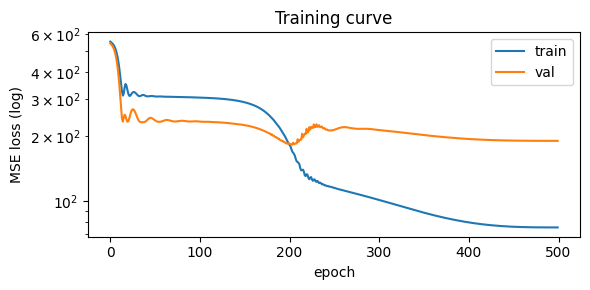

In [4]:
class EnergyNet(nn.Module):
    """MLP that maps sorted pairwise distances -> potential energy."""
    def __init__(self, n_features, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

n_train = int(0.8 * len(X_feat))
idx = np.random.permutation(len(X_feat))
train_i, val_i = idx[:n_train], idx[n_train:]

X_tr = torch.tensor(X_feat[train_i], dtype=torch.float32)
y_tr = torch.tensor(y[train_i], dtype=torch.float32)
X_va = torch.tensor(X_feat[val_i], dtype=torch.float32)
y_va = torch.tensor(y[val_i], dtype=torch.float32)

model = EnergyNet(n_features=X_feat.shape[1])
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=500)

train_losses, val_losses = [], []
for epoch in range(500):
    model.train(); opt.zero_grad()
    loss = nn.functional.mse_loss(model(X_tr), y_tr)
    loss.backward(); opt.step(); sched.step()
    train_losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        val_losses.append(nn.functional.mse_loss(model(X_va), y_va).item())
    if (epoch + 1) % 100 == 0:
        print(f'epoch {epoch+1:4d}  train MSE={train_losses[-1]:.4f}  val MSE={val_losses[-1]:.4f}')

plt.figure(figsize=(6, 3))
plt.semilogy(train_losses, label='train')
plt.semilogy(val_losses, label='val')
plt.xlabel('epoch'); plt.ylabel('MSE loss (log)')
plt.title('Training curve'); plt.legend()
plt.tight_layout(); plt.show()

## 4. Forces from autograd

To get forces from the network, we do NOT add a force output head. We differentiate the energy with respect to positions -- the same operation as the finite-difference check in Notebook 01, but exact and automatic.

```python
pos = torch.tensor(positions, requires_grad=True)
feat = pairwise_distances_torch(pos)   # sorted, graph kept
E = model(feat.unsqueeze(0))
E.backward()                           # dE/d(pos)
forces = -pos.grad                     # F = -dV/dr
```

Because the torch feature path sorts *with* the graph, this is the exact gradient of the same function the model was trained on. We confirm with the Notebook 01 gradient check.

In [5]:
def nn_energy(pos_np):
    """Network energy for numpy positions (uses the sorted numpy features)."""
    feat = torch.tensor(pairwise_distances(pos_np), dtype=torch.float32).unsqueeze(0)
    model.eval()
    with torch.no_grad():
        return model(feat).item()

def nn_forces(pos_np):
    """Forces via autograd (uses the sorted torch features -> consistent with nn_energy)."""
    pos = torch.tensor(pos_np, dtype=torch.float32, requires_grad=True)
    feat = pairwise_distances_torch(pos)          # (N*(N-1)/2,), sorted, graph kept
    model.eval()
    E = model(feat.unsqueeze(0))                  # (1,)
    E.backward()
    return -pos.grad.numpy()                      # F = -dE/dr

# ---- Gradient check (same idea as Notebook 01) ----
pos = triangular_lattice(3, 3) + 0.05 * np.random.randn(9, 2)
analytic = nn_forces(pos)

h = 1e-4
numerical = np.zeros_like(pos)
for i in range(pos.shape[0]):
    for k in range(pos.shape[1]):
        p_plus, p_minus = pos.copy(), pos.copy()
        p_plus[i, k] += h
        p_minus[i, k] -= h
        numerical[i, k] = -(nn_energy(p_plus) - nn_energy(p_minus)) / (2 * h)

max_err = np.max(np.abs(analytic - numerical))
rel_err = max_err / (np.abs(numerical).max() + 1e-12)
print(f'autograd vs numerical force:  max abs error {max_err:.4f},  relative error {rel_err:.2%}')
print('They agree to well under a percent -- the autograd force IS the gradient of the energy.')
print('The tiny residual is the non-differentiable points of sorting (two distances swapping')
print('rank), which is exactly the non-smoothness Notebook 04 removes with symmetry functions.')

# Note: the NN was trained on ENERGY only, so its forces need not match the true LJ forces
# (energy-only training does not constrain the gradient). Adding forces to the loss fixes
# this -- see Exercise 1. This is why we validate with energy conservation, not force accuracy.
lj_F = lj_forces(pos)
print(f'\n(For contrast) NN vs true LJ force, max diff: {np.max(np.abs(nn_forces(pos) - lj_F)):.2f}'
      '  <- large because training saw energies only, not forces')

autograd vs numerical force:  max abs error 0.0530,  relative error 0.11%
They agree to well under a percent -- the autograd force IS the gradient of the energy.
The tiny residual is the non-differentiable points of sorting (two distances swapping
rank), which is exactly the non-smoothness Notebook 04 removes with symmetry functions.

(For contrast) NN vs true LJ force, max diff: 27.53  <- large because training saw energies only, not forces


## 5. Run MD with the learned potential

Now we slot the neural-network forces into the same velocity-Verlet loop as Notebook 01. The only change is the force function. If the learned potential is physically reasonable, total energy should stay flat.

In [6]:
def run_md_nn(positions, velocities, dt=0.004, steps=1000, mass=1.0, record_every=10):
    """MD loop using the neural-network force instead of LJ."""
    pos = np.asarray(positions, dtype=float).copy()
    vel = np.asarray(velocities, dtype=float).copy()
    forces = nn_forces(pos)
    traj, pot, kin, tot = [], [], [], []
    for step in range(steps):
        if step % record_every == 0:
            u = nn_energy(pos)
            k = 0.5 * mass * np.sum(vel ** 2)
            traj.append(pos.copy()); pot.append(u); kin.append(k); tot.append(u + k)
        accel = forces / mass
        v_half = vel + 0.5 * accel * dt
        pos = pos + v_half * dt
        forces = nn_forces(pos)
        vel = v_half + 0.5 * (forces / mass) * dt
    return dict(traj=np.array(traj), potential=np.array(pot),
                kinetic=np.array(kin), total=np.array(tot))

print('Running NN-MD (this may take ~30 seconds on CPU)...')
start_pos = triangular_lattice(3, 3)
start_vel = thermal_velocities(9, d=2, temp=0.1, seed=5)

out_nn = run_md_nn(start_pos, start_vel, dt=0.003, steps=500, record_every=5)
out_lj = run_md(start_pos, start_vel, dt=0.003, steps=500, record_every=5)

nn_drift = (out_nn['total'].max() - out_nn['total'].min()) / abs(out_nn['total'].mean())
lj_drift = (out_lj['total'].max() - out_lj['total'].min()) / abs(out_lj['total'].mean())
print(f'NN total energy drift: {nn_drift:.3%}')
print(f'LJ total energy drift: {lj_drift:.3%}')

Running NN-MD (this may take ~30 seconds on CPU)...


NN total energy drift: 0.324%
LJ total energy drift: 0.001%


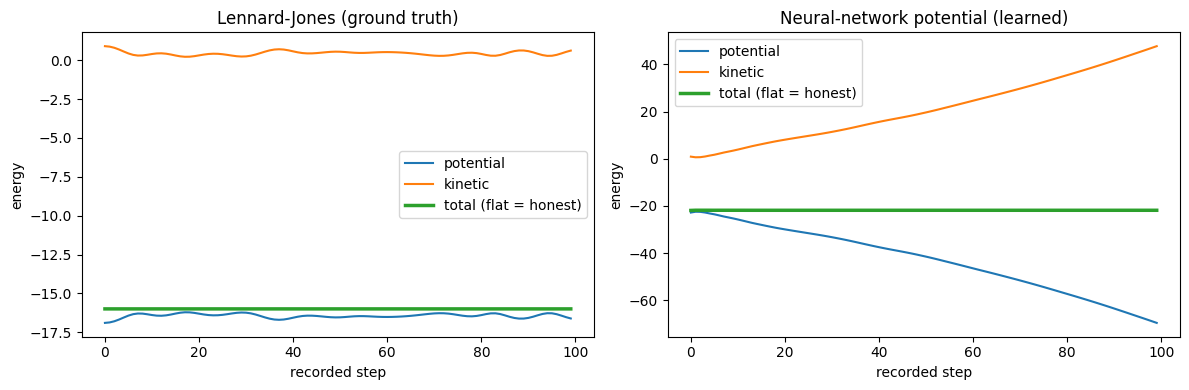

In [7]:
t = np.arange(len(out_nn['total']))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (out, title) in zip(axes, [
    (out_lj, 'Lennard-Jones (ground truth)'),
    (out_nn, 'Neural-network potential (learned)'),
]):
    ax.plot(t, out['potential'], label='potential')
    ax.plot(t, out['kinetic'], label='kinetic')
    ax.plot(t, out['total'], lw=2.5, label='total (flat = honest)')
    ax.set_xlabel('recorded step'); ax.set_ylabel('energy')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

## 6. What we built -- and what is still missing

You replaced the hand-written force with a learned one. The MD loop is untouched. The energy-conservation check is the same. Everything you would do to validate a classical force field applies here too -- that is the point.

**What we glossed over:**

1. **Sorted distances lose information and are non-smooth.** Sorting is permutation-invariant,    but the sort order can switch as atoms move, putting kinks in the features.    Notebook 04 replaces sorted distances with smooth symmetry functions.

2. **The network does not respect physical symmetries by construction.**    It must learn them from data, which needs far more data than an architecture that    encodes symmetry by design. Notebook 04 shows how.

3. **There is no cutoff.** Real potentials only include atoms within a cutoff radius.    Our feature vector grows as $N^2$. Notebooks 04-05 fix this.

4. **Silent failure is possible.** On a configuration far from the training set -- two atoms    too close, a species not in the data -- the network still returns a number, with no warning.    Notebook 07 is about catching exactly this.

### Exercises

1. **Force training.** Add forces to the loss: `loss = alpha * E_loss + beta * F_loss`.    How does including force labels change the MD quality?

2. **Cutoff.** Modify `pairwise_distances` to only include pairs closer than `r_cut = 3.0`.    Does the model still work? Does training speed up?

3. **Out-of-distribution check.** Evaluate `nn_energy` on a configuration with two atoms at    distance 0.5 (never in training). Compare to `lj_energy`. Is the prediction physical?